___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Processing Images

In this notebook, we will learn the steps of image preprocessing that are necessary for a deep agent to work properly on images. <br />
As already mentioned in the last lecture, when dealing with image data, we often need to store multiple sequential frames in order to feed all available data to the agent. <br />
It is not possible to decide whether a ball moves to the left or to the right given only a single image. <br />
keras-rl provides a class called **Processor** which is used to process the image data before it gets fed into the backbone network

Let us first start by importing the necessary libraries

In [1]:
from PIL import Image # To handle images

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackened.format_figure = "retina"

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
import gymnasium as gym
from gymnasium.utils import play # to play manually

In [6]:
from rl.core import Processor
from rl.memory import SequentialMemory # To store the sequential frames

In [7]:
import ale_py
from ale_py import ALEInterface ,  roms

In [8]:
ale = ALEInterface()
ale.loadROM(roms.get_rom_path("breakout"))

Let us first create an image based environment, namely the famous game called **Breakout** (https://gymnasium.farama.org/v0.26.3/environments/atari/breakout/)

In [9]:
gym.register_envs(ale_py)
env = gym.make("ALE/Breakout-v5" , render_mode = "rgb_array")

Of course we can also play the game manually. <br />
Feel free to try it out: <br />
Use the **a** and **d** key to move the bar and space to start the round<br />
(Notice how for the image based atari environments we can directly use a **play** function provided by gym to play the game)

In [10]:
play.play(env)

We need to decide how many sequential frames are necessary to capture all information.<br/>
Let's go with 3.<br/>
This is also called window_length, which we need to pass to the **SequentialMemory**

In [11]:
WINDOW_LENGTH = 5

What replay memory effectively does, is that it appends WINDOW_LENGTH sequential frames to a list and then appends this whole list to the memory.
Thus a single element from our SequentialMemory contains WINDOW_LENGTH (consecutive images) <br />
The code snipped below demonstrates a basic implementation of this routine

In [12]:
from collections import deque

In [13]:
np.random.seed(42)
env.reset()
# [[0,1,2],[1,2,3],[2,3,4]]
sequential_frame_buffer = []  # Our actual memory

temp_sequential_frames = deque(maxlen = WINDOW_LENGTH)

for i in range(10):
    if i == 1:
        action = 1
    else:
        action = 3 # we go to left.
    observation , reward , truncated , terminated , info = env.step(action)
    done = truncated or terminated
    if len(temp_sequential_frames) == WINDOW_LENGTH:
        sequential_frame_buffer.append(list(temp_sequential_frames))

    temp_sequential_frames.append(observation)

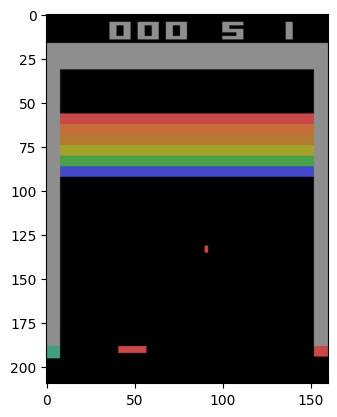

In [16]:
%matplotlib inline
if len(sequential_frame_buffer) > 0:
    plt.imshow(sequential_frame_buffer[0][3])
    plt.show() # Add this to actually render the plot
else:
    print("Buffer is empty. Try increasing the loop range.")

We can now plot the consecutive images stored in each timestep. <br />
Each row visualizes one element of our *sequential_frame_buffer*

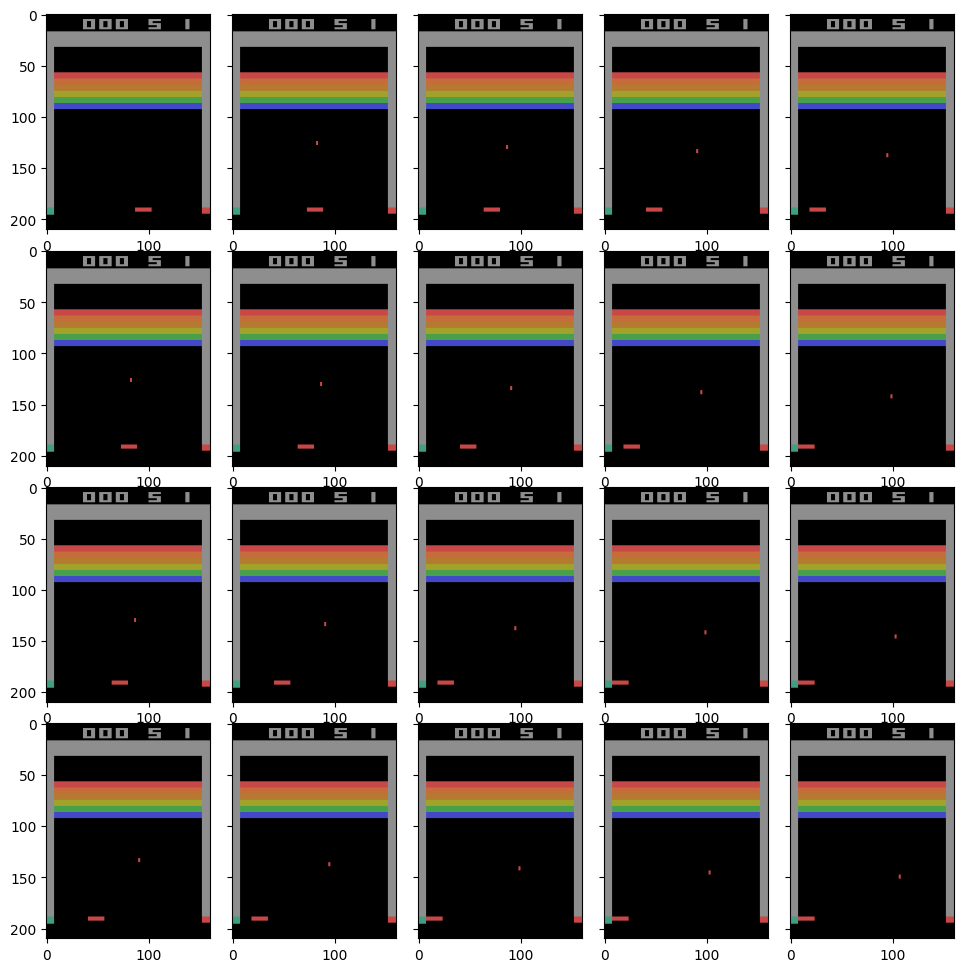

In [15]:
%matplotlib inline

fig, axis = plt.subplots(4, WINDOW_LENGTH, figsize=(12, 12) , sharey="all")

for global_index, timestep in enumerate(sequential_frame_buffer[:4]):
    for frame_index, frame in enumerate(timestep):
        axis[global_index][frame_index].imshow(frame)

fig.subplots_adjust(wspace=0, hspace=0.1)

Of course we do not have to do this by ourselves as keras-rl does it automatically if WINDOW_LENGTH is larger than 1

In [17]:
frame.max()

200

In [18]:
# does the same thing in a much more optimized way
memory = SequentialMemory(limit=1000, window_length=WINDOW_LENGTH)

Besides that we need to decide how large our images should be. <br />
Larger images might contain more information but also increase the training time. <br />
Let us use an image size of $84\times84$

In [19]:
IMG_SHAPE = (84, 84)

Now we can create image processing class, which inherits the **Processor** provided by keras-rl (https://github.com/keras-rl/keras-rl/blob/master/rl/core.py#L515)

Each processor can define the following methods:
1. *process_step(observation, reward, done, info)* ("Processes an entire step by applying the processor to the observation, reward, and info arguments". Used during inference)
2. *process_observation(observation)* ("Processes the observation as obtained from the environment for use in an agent and returns it")
3. *process_reward(reward)* ("Processes the reward as obtained from the environment for use in an agent and returns it")
4. *process_info(info)* ("Processes the info as obtained from the environment for use in an agent and returns it)
5. *process_action(action)* ("Processes an action predicted by an agent but before execution in an environment")
6. *process_state_batch(batch)* ("Processes an entire batch of states and returns it". Used for training)

The overall use of the processor is to act as a "translator" which translates the observation provided by gym into something our network can handle

Let's define our first processor, called **BreakOutProcessor**
As we do not train in this notebook, we only overwrite the *process_observation* function. <br />
This function has to perform two operations:
1. Resize the image to our desired shape
2. Convert it to grayscale (as the colored images do not yield any more information in this case)
We will use PIL to perform those tasks

In [21]:
from rl.core import Processor

In [22]:
class BreakOutProcessor(Processor):
    def process_observation(self, observation):
        # First convert the numpy array to a PIL Image
        img = Image.fromarray(observation)
        # Then resize the image
        img = img.resize(IMG_SHAPE)
        # And convert it to grayscale  (The L stands for luminance)
        img = img.convert("L")
        # Finally we convert the image back to a numpy array and return it
        return np.array(img)

We can now try the processor

In [23]:
sample_images = []
breakout_proc = BreakOutProcessor()
env.reset()
for _ in range(200):
    action = env.action_space.sample()  # sample a random action
    observation, reward , truncated , terminared , info = env.step(action)  # and perform it on the environment to get the next state
    done = truncated or terminated
    processed_observation = breakout_proc.process_observation(observation)
    sample_images.append(processed_observation)

In [24]:
print(f"The shape of the original observation is {observation.shape} " \
        f"and the shape of the processed observation is {processed_observation.shape}")

The shape of the original observation is (210, 160, 3) and the shape of the processed observation is (84, 84)


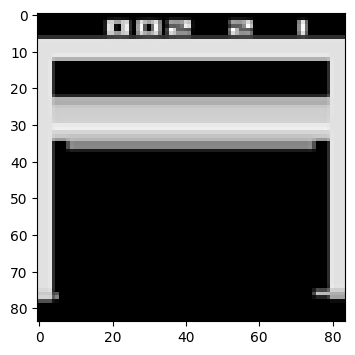

In [29]:
plt.figure(figsize = (5,4))
plt.imshow(sample_images[-1], cmap="gray")
plt.show()